# <font color="blue">**Gravitational Waves**</font>

<img src="https://raw.githubusercontent.com/deltorobarba/science/main/nature.JPG" alt="science">


In [ ]:
!pip install -q gwpy gwosc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gwosc.api import fetch_allevents_json
from gwosc.datasets import event_gps, event_detectors
from gwpy.timeseries import TimeSeries

plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", None)

In [ ]:
# 1. Connect to GWOSC (Gravitational Wave Open Science Center) from on LIGO/Virgo/KAGRA and Fetch Events
catalog_raw = fetch_allevents_json()["events"]
print(f"{len(catalog_raw)} Records in the catalog (including multiple versions per event)")

rows = []
for key, meta in catalog_raw.items():
    rows.append({
        "dataset_key": key,
        "event": meta.get("commonName"),
        "version": meta.get("version"),
        "catalog": meta.get("catalog.shortName"),
        "gps": meta.get("GPS"),
        "mass_1_source": meta.get("mass_1_source"),
        "mass_2_source": meta.get("mass_2_source"),
        "chirp_mass_source": meta.get("chirp_mass_source"),
        "network_snr": meta.get("network_matched_filter_snr"),
        "distance_mpc": meta.get("luminosity_distance"),
    })

events_df = pd.DataFrame(rows)

# Retain only the latest data version per event
events_df = (
    events_df.sort_values("version")
              .drop_duplicates(subset="event", keep="last")
              .reset_index(drop=True)
)
print(f"{len(events_df)} unique events found")
#events_df.head()

print("✅ Filter Top-K Events by network SNR (statistically significant detection)")
K = 10
top_k = (
    events_df.dropna(subset=["network_snr"])
              .sort_values("network_snr", ascending=False)
              .head(K)
)
top_k[["event", "catalog", "network_snr", "mass_1_source", "mass_2_source", "distance_mpc"]]

671 Records in the catalog (including multiple versions per event)
433 unique events found
✅ Filter Top-K Events by network SNR (statistically significant detection)


,event,catalog,network_snr,mass_1_source,mass_2_source,distance_mpc
348,GW250114_082203,GWTC-5.0,78.60,33.76,32.26,405.0
242,GW250207_115645,O4_Discovery_Papers,68.91,35.20,30.60,187.0
404,GW230814_230901,GWTC-4.1,43.00,33.70,28.20,290.0
69,GW240920_124024,GWTC-5.0,37.40,37.10,31.90,1090.0
355,GW241011_233834,GWTC-5.0,35.80,19.50,5.96,212.0
381,GW231226_101520,GWTC-4.1,34.70,40.20,35.10,1180.0
424,GW170817,GWTC-1-confident,33.00,1.46,1.27,40.0
238,GW241127_061008,GWTC-5.0,31.30,63.80,20.80,1080.0
356,GW240925_005809,GWTC-5.0,31.20,9.02,6.99,356.0
260,GW230627_015337,GWTC-4.1,28.70,8.40,5.74,305.0


In [ ]:
# 2. Select specific event (GW150914 for first detection in 2015, GW170817 for neutron star merger)

SELECTED_EVENT = "GW150914"  # <- Enter event names from table above

info = events_df.loc[events_df["event"] == SELECTED_EVENT].iloc[0]
gps = event_gps(SELECTED_EVENT)
detectors = sorted(event_detectors(SELECTED_EVENT))
DETECTOR = detectors[0]  # Select a different detector from the list if necessary.

print(f"Event:          {SELECTED_EVENT}")
print(f"GPS time:        {gps}")
print(f"Detector:      {detectors}  -> use '{DETECTOR}'")
print(f"Mass (M_sun):  {info['mass_1_source']:.1f} + {info['mass_2_source']:.1f}")
print(f"Network-SNR:    {info['network_snr']:.1f}")
print(f"Distance:      {info['distance_mpc']:.0f} Mpc")

Event:          GW150914
GPS time:        1126259462.4
Detector:      ['H1', 'L1']  -> use 'H1'
Mass (M_sun):  34.6 + 30.0
Network-SNR:    26.0
Distance:      470 Mpc


Detector: H1. Duration: 32.0 s. Sample rate: 4096.0 Hz. Values: 131072



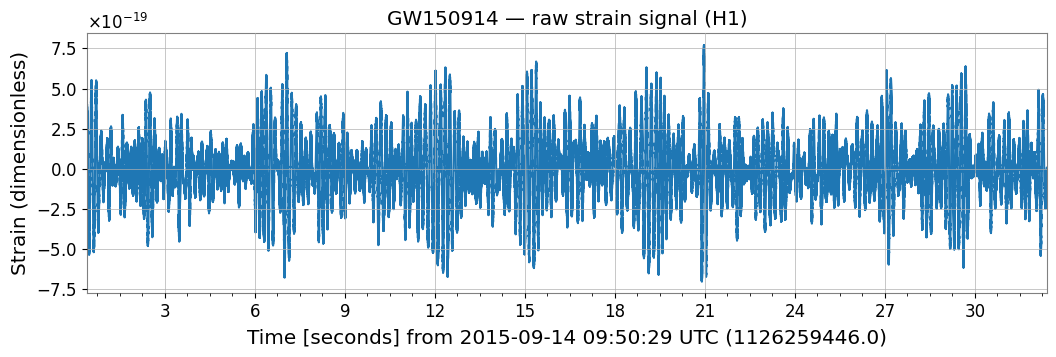

In [ ]:
# 3. Load raw strain data from detector around time of event

PADDING = 16  # Seconds of raw data before/after the event
start, end = gps - PADDING, gps + PADDING
strain = TimeSeries.fetch_open_data(DETECTOR, start, end, sample_rate=4096, cache=True)
print(f"Detector: {DETECTOR}. Duration: {strain.duration}. Sample rate: {strain.sample_rate}. Values: {len(strain)}\n")
#strain_stats = pd.Series(strain.value, name="strain").describe()
#display(strain_stats)
plot = strain.plot() # Time-series plot (signal still hidden in noise)
ax = plot.gca()
ax.set_ylabel("Strain (dimensionless)")
ax.set_title(f"{SELECTED_EVENT} — raw strain signal ({DETECTOR})")
plot.show()

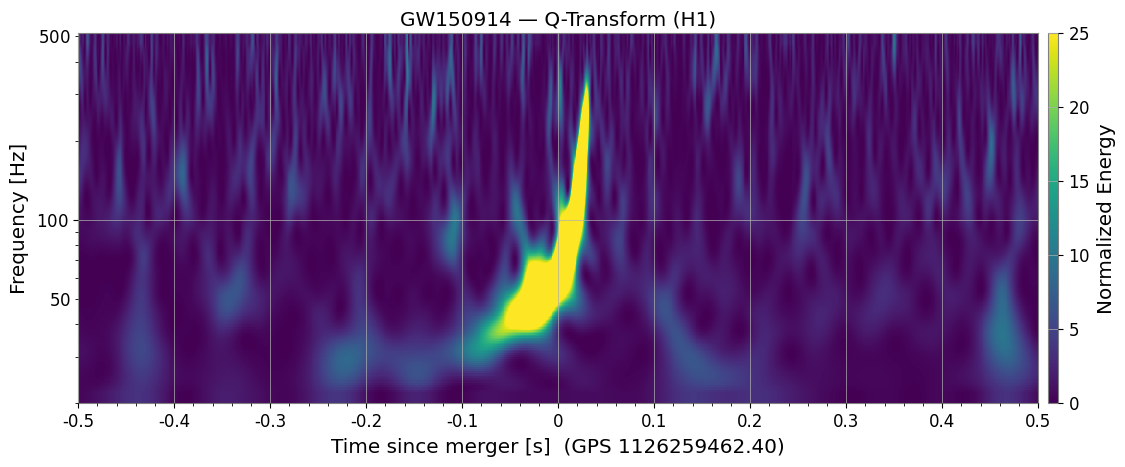

In [ ]:
# 4. Q-Transform to make the chirp visible (Remove noise from signal via whitening)

QRANGE = (4, 64)      # Q-Range of transform
FRANGE = (20, 512)    # Frequency range in Hz
WINDOW = 0.5          # Seconds around the merger that are being plotted

white_strain = strain.whiten()
qspec = white_strain.q_transform(
    qrange=QRANGE,
    frange=FRANGE,
    outseg=(gps - WINDOW, gps + WINDOW),
)

plot = qspec.plot(figsize=(12, 5)) # Time-frequency spectrogram using Q-transform
ax = plot.gca()
ax.set_xscale("seconds", epoch=gps)
ax.set_yscale("log")
ax.set_ylim(*FRANGE)
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel(f"Time since merger [s]  (GPS {gps:.2f})")
ax.set_title(f"{SELECTED_EVENT} — Q-Transform ({DETECTOR})")
ax.colorbar(label="Normalized Energy", clim=(0, 25))
plot.show()